# Nhận dạng ảnh Chó/Mèo bằng Logistic Regression (Phiên bản tối ưu)
**Đề tài:** Dog and Cat Classification using Logistic Regression

**Dataset:** [Cat & Dog dataset trên Kaggle](https://www.kaggle.com/datasets/tongpython/cat-and-dog)

---

### Mô hình ML được áp dụng
**Logistic Regression** — là thuật toán phân loại tuyến tính.
Mô hình học một đường ranh giới trong không gian đặc trưng để phân biệt 2 lớp: **Cat (0)** và **Dog (1)**.

### Các cải tiến trong phiên bản này
1. **Trích xuất đặc trưng HOG** — thay vì dùng pixel thô, HOG giúp trích xuất thông tin về hình dáng và cạnh.
2. **Resize with Padding** — giữ tỉ lệ khung hình, tránh méo ảnh.
3. **Chuẩn hóa dữ liệu bằng StandardScaler** — giúp thuật toán tối ưu hội tụ nhanh hơn.
4. **Giảm chiều bằng PCA** — loại bỏ các đặc trưng nhiễu, giữ lại thông tin quan trọng.
5. **GridSearchCV** — tự động tìm bộ tham số tối ưu (C, n_components).
6. **Confidence Score + Ngưỡng chặn Unknown** — phân biệt ảnh không phải chó/mèo.

## Bước 1: Import thư viện & Khởi tạo môi trường
- **Mục đích:** Khai báo các công cụ cần thiết và kiểm tra xem dữ liệu (dataset) đã sẵn sàng chưa trước khi bắt đầu xử lý.
- **Công cụ sử dụng:** `os` để làm việc với file/thư mục, `matplotlib.pyplot`, `cv2` để hiển thị và xử lý ảnh, cùng các thư viện Machine Learning cơ bản.

In [1]:
import os
import cv2
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, log_loss
)

In [4]:
# Kiểm tra cấu trúc và số lượng ảnh trong dataset
train_cat = len(os.listdir("Cat_Dog_data/train/cat"))
train_dog = len(os.listdir("Cat_Dog_data/train/dog"))
test_cat = len(os.listdir("Cat_Dog_data/test/cat"))
test_dog = len(os.listdir("Cat_Dog_data/test/dog"))

print(f"=== Thống kê Dataset ===")
print(f"Train: {train_cat} ảnh mèo + {train_dog} ảnh chó = {train_cat + train_dog} ảnh")
print(f"Test:  {test_cat} ảnh mèo + {test_dog} ảnh chó = {test_cat + test_dog} ảnh")
print(f"Tổng cộng: {train_cat + train_dog + test_cat + test_dog} ảnh")
print(f"\nTỷ lệ Cat:Dog = {train_cat}:{train_dog} → {'Cân bằng' if train_cat == train_dog else 'Không cân bằng!'}")

=== Thống kê Dataset ===
Train: 11250 ảnh mèo + 11250 ảnh chó = 22500 ảnh
Test:  1250 ảnh mèo + 1250 ảnh chó = 2500 ảnh
Tổng cộng: 25000 ảnh

Tỷ lệ Cat:Dog = 11250:11250 → Cân bằng


## Bước 2: Đọc thử 1 ảnh — Hiểu dữ liệu thô
- **Mục đích:** Tải một ảnh lên và hiển thị để xem kích thước, cấu trúc màu sắc ban đầu của dữ liệu thô trước khi áp dụng phép biến đổi.
- **Công cụ sử dụng:** `cv2.imread` (OpenCV) để đọc ảnh thô thành ma trận pixel, và `matplotlib.pyplot` để vẽ ảnh.

In [5]:
# Tìm 1 ảnh mèo có thật trong thư mục
sample_file = os.listdir("Cat_Dog_data/train/cat")[0]
sample_path = os.path.join("Cat_Dog_data/train/cat", sample_file)

img_raw = cv2.imread(sample_path)
print(f"Ảnh mẫu: {sample_file}")
print(f"Kích thước gốc (H x W x Channels): {img_raw.shape}")
print(f"Kiểu dữ liệu: {img_raw.dtype}")
print(f"Giá trị pixel: min={img_raw.min()}, max={img_raw.max()}")

Ảnh mẫu: cat.0.jpg
Kích thước gốc (H x W x Channels): (374, 500, 3)
Kiểu dữ liệu: uint8
Giá trị pixel: min=0, max=255


## Bước 3: Trích xuất đặc trưng HOG — Tại sao dùng HOG thay vì Raw Pixel?
- **Mục đích:** Biến đổi ảnh thô thành một "bản phác thảo" (vector đặc trưng) tập trung vào hình dáng và đường viền của vật thể, loại bỏ nhiễu về màu sắc và ánh sáng nền.
- **Công cụ sử dụng:** Thuật toán `hog` từ thư viện `skimage.feature`.

### Tại sao HOG giúp nhận diện tốt hơn Raw Pixel?
**Raw Pixel** = đưa thẳng 64×64×3 = 12,288 giá trị màu vào model.
- Giống như đọc sách bằng cách nhìn từng hạt mực → chỉ thấy "đen, trắng" mà không thấy chữ. Rất nhạy với ánh sáng, màu nền.

**HOG (Histogram of Oriented Gradients)** = trích xuất "bản phác thảo".
- HOG tìm **cạnh và đường viền** bằng cách chia ảnh thành lưới các ô nhỏ (ví dụ 8x8 pixel).
- Tại mỗi ô, nó đo lường độ dốc của ánh sáng để biết cạnh đó hướng về đâu.
- **Làm sao HOG nhìn ra cái thân từ ô 8x8?** Một ô 8x8 chỉ là một mẩu của đường viền. Nhưng HOG giữ nguyên **thứ tự tọa độ không gian** của các ô. Hàng chục ô 8x8 liên tiếp ở giữa ảnh cùng báo cáo về đường viền ngang sẽ được model học và hiểu đó là "lưng" của con vật.
- Kết quả: Ảnh được mã hóa thành 1 vector 8,100 số mô tả cấu trúc hình dáng toàn cục.

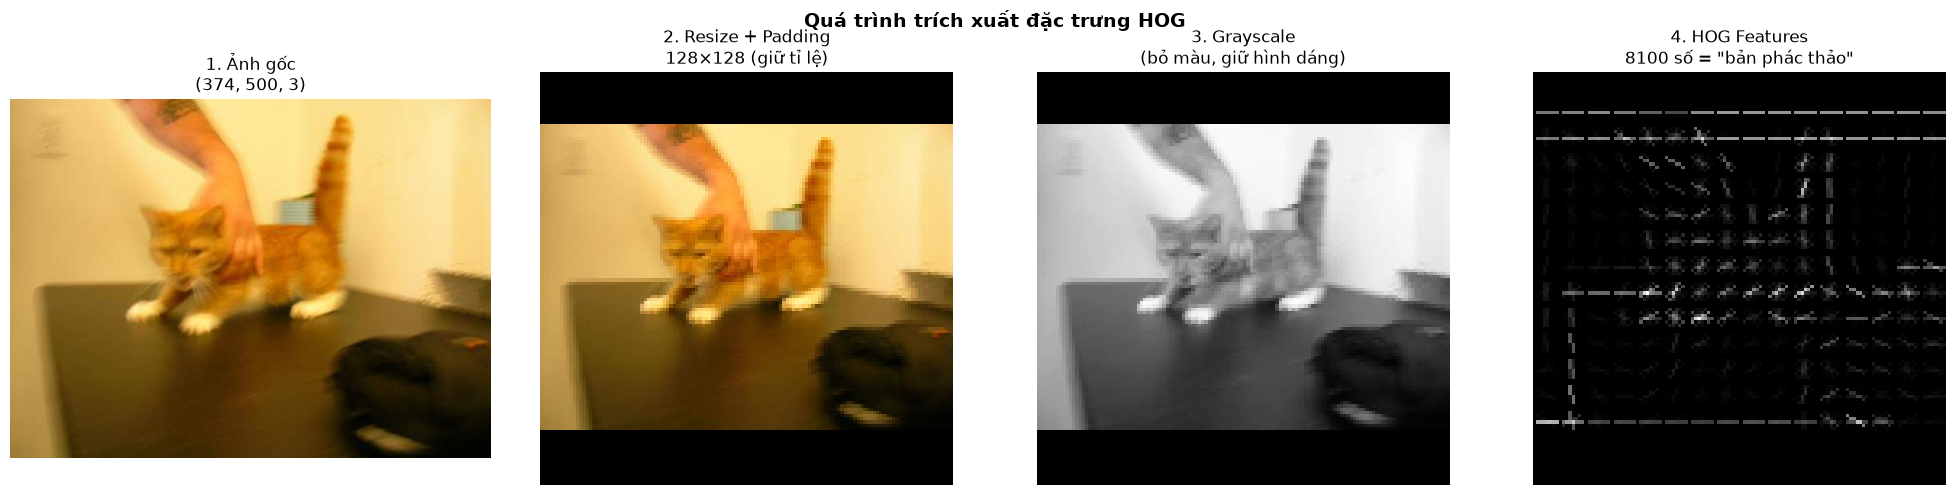


→ Raw pixel (RGB): 128×128×3 = 49152 features
→ HOG features: 8100 features
→ HOG giảm 6.1 lần, nhưng chứa thông tin HÌNH DÁNG tốt hơn!


In [6]:
# Minh họa trực quan: HOG biến ảnh thành "bản phác thảo" như thế nào
IMG_SIZE = 128

img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize giữ tỉ lệ (padding)
def resize_with_padding(img, target_size):
    """Resize giữ nguyên tỉ lệ khung hình, pad thêm viền đen cho đủ kích thước.
    
    Tránh méo hình dạng con vật so với việc dùng cv2.resize() kéo giãn trực tiếp
    khi ảnh gốc không có tỉ lệ khung hình vuông.
    """
    h, w = img.shape[:2]
    target_w, target_h = target_size, target_size

    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))

    resized = cv2.resize(img, (new_w, new_h))

    if img.ndim == 3:
        canvas = np.zeros((target_h, target_w, img.shape[2]), dtype=img.dtype)
    else:
        canvas = np.zeros((target_h, target_w), dtype=img.dtype)

    top = (target_h - new_h) // 2
    left = (target_w - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    return canvas

# So sánh resize thường vs resize with padding
img_stretch = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_padded = resize_with_padding(img_rgb, IMG_SIZE)

# Tạo HOG visualization
img_gray_padded = cv2.cvtColor(resize_with_padding(img, IMG_SIZE), cv2.COLOR_BGR2GRAY)
hog_features, hog_image = hog(
    img_gray_padded,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True
)

# Hiển thị 4 bước
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_rgb)
axes[0].set_title(f'1. Ảnh gốc\n{img_rgb.shape}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_padded)
axes[1].set_title(f'2. Resize + Padding\n{IMG_SIZE}×{IMG_SIZE} (giữ tỉ lệ)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(img_gray_padded, cmap='gray')
axes[2].set_title(f'3. Grayscale\n(bỏ màu, giữ hình dáng)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(hog_image, cmap='gray')
axes[3].set_title(f'4. HOG Features\n{hog_features.shape[0]} số = "bản phác thảo"', fontsize=12)
axes[3].axis('off')

plt.suptitle('Quá trình trích xuất đặc trưng HOG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n→ Raw pixel (RGB): {IMG_SIZE}×{IMG_SIZE}×3 = {IMG_SIZE*IMG_SIZE*3} features")
print(f"→ HOG features: {hog_features.shape[0]} features")
print(f"→ HOG giảm {IMG_SIZE*IMG_SIZE*3 / hog_features.shape[0]:.1f} lần, nhưng chứa thông tin HÌNH DÁNG tốt hơn!")

## Bước 4: Load toàn bộ dữ liệu (Tiền xử lý & Trích xuất đặc trưng)
- **Mục đích:** Xử lý hàng loạt toàn bộ ảnh trong dataset: Đảm bảo tất cả ảnh đều vuông (bằng cách thêm viền padding đen tránh méo ảnh), sau đó trích xuất vector HOG cho mỗi ảnh và gắn nhãn (0 cho Mèo, 1 cho Chó).
- **Công cụ sử dụng:** Viết hàm dùng OpenCV (`cv2.copyMakeBorder`, `cv2.resize`) để padding ảnh và `skimage.feature.hog` để lấy đặc trưng. Dữ liệu được lưu trong mảng `numpy`.

In [7]:
IMG_SIZE = 128
import gc

def extract_hog_features(image_path):
    """Đọc ảnh, resize giữ tỉ lệ, chuyển grayscale và trích xuất đặc trưng HOG."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = resize_with_padding(img, IMG_SIZE)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )
    # Ép kiểu float32 để giảm nửa bộ nhớ (từ float64 mặc định)
    return features.astype(np.float32)

def load_dataset_optimized(folder_cat, folder_dog):
    files_cat = os.listdir(folder_cat)
    files_dog = os.listdir(folder_dog)
    total_imgs = len(files_cat) + len(files_dog)
    
    # Khởi tạo sẵn mảng NumPy float32 thay vì dùng list append và nối list
    # 8100 là số lượng features cho ảnh 128x128 với parameters HOG trên
    X = np.zeros((total_imgs, 8100), dtype=np.float32)
    y = np.zeros(total_imgs, dtype=np.int8)
    
    idx = 0
    print(f"  Đang load Cat ({len(files_cat)} ảnh)...")
    for file in files_cat:
        img_path = os.path.join(folder_cat, file)
        feat = extract_hog_features(img_path)
        if feat is not None:
            X[idx] = feat
            y[idx] = 0
            idx += 1
            
    print(f"  Đang load Dog ({len(files_dog)} ảnh)...")
    for file in files_dog:
        img_path = os.path.join(folder_dog, file)
        feat = extract_hog_features(img_path)
        if feat is not None:
            X[idx] = feat
            y[idx] = 1
            idx += 1
            
    return X[:idx], y[:idx]

start = time.time()

print("Đang load tập Train...")
X_train, y_train = load_dataset_optimized("Cat_Dog_data/train/cat", "Cat_Dog_data/train/dog")

print("Đang load tập Test...")
X_test, y_test = load_dataset_optimized("Cat_Dog_data/test/cat", "Cat_Dog_data/test/dog")

# Gọi thu gom rác bộ nhớ
gc.collect()

elapsed = time.time() - start
print(f"\n=== Kết quả ===")
print(f"X_train: {X_train.shape} (Dung lượng: {X_train.nbytes / (1024*1024):.1f} MB)")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Thời gian load: {elapsed:.1f} giây")

Đang load tập Train...
  Đang load Cat (11250 ảnh)...
  Đang load Dog (11250 ảnh)...
Đang load tập Test...
  Đang load Cat (1250 ảnh)...
  Đang load Dog (1250 ảnh)...

=== Kết quả ===
X_train: (22500, 8100) (Dung lượng: 695.2 MB)
y_train: (22500,)
X_test:  (2500, 8100)
y_test:  (2500,)
Thời gian load: 989.7 giây


## Bước 5: Xây dựng Pipeline Machine Learning
- **Mục đích:** Ghép nối các bước xử lý dữ liệu và huấn luyện thành một quy trình chuẩn xác, tự động và tránh rò rỉ dữ liệu (data leakage) giữa tập train/test.
- **Công cụ sử dụng:** `Pipeline` từ thư viện `sklearn.pipeline`.

### Chi tiết các bước trong Pipeline:
1. **⚖️ StandardScaler — "Đưa tất cả về cùng 1 thang đo"**
   - **Mục đích:** Chuyển đổi các giá trị HOG về trung bình = 0 và độ lệch chuẩn = 1. Giúp các đặc trưng công bằng, thuật toán hội tụ nhanh.
   - **Công cụ sử dụng:** `StandardScaler` từ `sklearn.preprocessing`.

2. **🔽 PCA (Principal Component Analysis) — "Nén thông tin, bỏ nhiễu"**
   - **Mục đích:** Giảm chiều vector HOG từ 8,100 xuống vài trăm chiều. Giữ lại các hướng có *phương sai lớn nhất* (khác biệt rõ nhất giữa các ảnh), bỏ qua các ô 8x8 toàn màu nền, giúp mô hình nhẹ và giảm Overfitting.
   - **Công cụ sử dụng:** `PCA` từ `sklearn.decomposition`.

3. **🧠 Logistic Regression — "Vẽ đường phân chia"**
   - **Mục đích:** Thuật toán phân loại chính. Vẽ một đường ranh giới trong không gian PCA để tách biệt Chó và Mèo. Có khả năng trả về xác suất % để lọc ảnh rác.
   - **Công cụ sử dụng:** `LogisticRegression` từ `sklearn.linear_model`.

## Bước 6: GridSearchCV — Tối ưu hóa siêu tham số (Hyperparameter Tuning)
- **Mục đích:** Thay vì tự đoán bừa các cấu hình cho mô hình, hệ thống sẽ thử nghiệm nhiều tổ hợp khác nhau và tự chọn ra cấu hình mang lại độ chính xác cao nhất.
- **Công cụ sử dụng:** `GridSearchCV` từ thư viện `sklearn.model_selection`.

**GridSearchCV sẽ làm gì?**
Nó sẽ thử nghiệm chéo (Cross-validation) các tham số:
- **PCA n_components**: [150, 200, 300] — Tìm ra số lượng chiều dữ liệu tối ưu cần giữ lại.
- **LR C**: [0.1, 0.5, 1.0, 5.0] — Tham số điều chuẩn. C nhỏ giúp đường ranh giới đơn giản (chống học vẹt - overfit), C lớn giúp bám sát dữ liệu.

In [8]:
# Tạo pipeline cơ bản
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42)),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

# Các tổ hợp tham số cần thử
param_grid = {
    'pca__n_components': [150, 200, 300],
    'classifier__C': [0.1, 0.5, 1.0, 5.0]
}

print(f"Bắt đầu GridSearchCV...")
print(f"Số tổ hợp: {len(param_grid['pca__n_components']) * len(param_grid['classifier__C'])} × 5 folds")
print(f"(Quá trình này có thể mất 10-20 phút với full dataset)\n")

start_time = time.time()

grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=2,           # Giới hạn 2 tiến trình để tránh tràn RAM
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

search_time = time.time() - start_time
print(f"\n=== Kết quả GridSearchCV ===")
print(f"Thời gian: {search_time:.1f} giây")
print(f"Tham số tốt nhất: {grid_search.best_params_}")
print(f"Accuracy CV tốt nhất: {grid_search.best_score_ * 100:.2f}%")

Bắt đầu GridSearchCV...
Số tổ hợp: 12 × 5 folds
(Quá trình này có thể mất 10-20 phút với full dataset)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Kết quả GridSearchCV ===
Thời gian: 1489.3 giây
Tham số tốt nhất: {'classifier__C': 0.1, 'pca__n_components': 300}
Accuracy CV tốt nhất: 73.56%


In [9]:
# Hiển thị kết quả chi tiết của tất cả tổ hợp tham số
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
results_summary = cv_results[['param_pca__n_components', 'param_classifier__C',
                               'mean_train_score', 'mean_test_score', 'std_test_score']].copy()
results_summary.columns = ['PCA_n', 'C', 'Train_Acc', 'CV_Acc', 'CV_Std']
results_summary['Train_Acc'] = (results_summary['Train_Acc'] * 100).round(2)
results_summary['CV_Acc'] = (results_summary['CV_Acc'] * 100).round(2)
results_summary['CV_Std'] = (results_summary['CV_Std'] * 100).round(2)
results_summary = results_summary.sort_values('CV_Acc', ascending=False)

print("=== Bảng kết quả tất cả tổ hợp ===")
print(results_summary.to_string(index=False))
print(f"\n→ Tổ hợp tốt nhất: PCA={grid_search.best_params_['pca__n_components']}, "
      f"C={grid_search.best_params_['classifier__C']}")

=== Bảng kết quả tất cả tổ hợp ===
 PCA_n   C  Train_Acc  CV_Acc  CV_Std
   300 0.1      74.83   73.56    0.74
   300 5.0      74.84   73.56    0.74
   300 1.0      74.84   73.56    0.74
   300 0.5      74.84   73.56    0.74
   200 5.0      74.06   73.22    0.45
   200 1.0      74.06   73.21    0.47
   200 0.1      74.06   73.21    0.45
   200 0.5      74.06   73.20    0.45
   150 0.5      73.68   73.02    0.55
   150 0.1      73.69   73.02    0.53
   150 1.0      73.68   73.02    0.53
   150 5.0      73.68   73.02    0.53

→ Tổ hợp tốt nhất: PCA=300, C=0.1


## Bước 7: Huấn luyện mô hình tối ưu (Training)
- **Mục đích:** Sử dụng bộ cấu hình tốt nhất mà GridSearchCV vừa tìm được để huấn luyện lại một lần cuối cùng trên toàn bộ dữ liệu huấn luyện (Train set).
- **Công cụ sử dụng:** Phương thức `.fit(X_train, y_train)` của đối tượng `GridSearchCV` (tự động dùng `best_estimator_`).

In [10]:
# Lấy model tốt nhất từ GridSearchCV (đã được train trên toàn bộ tập train)
best_model = grid_search.best_estimator_

# In thông tin model
best_pca_n = grid_search.best_params_['pca__n_components']
best_C = grid_search.best_params_['classifier__C']
pca_variance = best_model.named_steps['pca'].explained_variance_ratio_.sum() * 100

print(f"=== Mô hình tối ưu ===")
print(f"Pipeline: StandardScaler → PCA({best_pca_n}) → LogisticRegression(C={best_C})")
print(f"Số PCA components: {best_pca_n}")
print(f"Phương sai được giữ lại: {pca_variance:.1f}%")
print(f"Hệ số regularization C: {best_C}")

=== Mô hình tối ưu ===
Pipeline: StandardScaler → PCA(300) → LogisticRegression(C=0.1)
Số PCA components: 300
Phương sai được giữ lại: 61.3%
Hệ số regularization C: 0.1


## Bước 8: Đánh giá mô hình (Evaluation)
- **Mục đích:** Đo lường xem mô hình học tốt đến đâu trên tập dữ liệu kiểm thử (Test set) - là những dữ liệu mô hình chưa từng được thấy.
- **Công cụ sử dụng:** `classification_report`, `accuracy_score` và `confusion_matrix` từ `sklearn.metrics`.
- **Kết quả hiển thị:** Độ chính xác tổng thể (Accuracy), Precision (độ chuẩn xác), Recall (độ bao phủ) và Ma trận nhầm lẫn (để xem có hay nhầm Chó thành Mèo không).

In [11]:
# Dự đoán trên tập train (kiểm tra overfitting)
pred_train = best_model.predict(X_train)
acc_train = accuracy_score(y_train, pred_train)

# Dự đoán trên tập test
pred_test = best_model.predict(X_test)
acc_test = accuracy_score(y_test, pred_test)

print(f"=== Kết quả Đánh giá ===")
print(f"Accuracy trên tập TRAIN: {acc_train * 100:.2f}%")
print(f"Accuracy trên tập TEST:  {acc_test * 100:.2f}%")
print(f"Chênh lệch Train - Test: {(acc_train - acc_test) * 100:.2f}%")

if (acc_train - acc_test) > 10:
    print("→ Nhận xét: Chênh lệch > 10% → Có dấu hiệu Overfitting.")
else:
    print("→ Nhận xét: Chênh lệch hợp lý → Mô hình khái quát hóa tốt (không Overfitting).")

=== Kết quả Đánh giá ===
Accuracy trên tập TRAIN: 74.65%
Accuracy trên tập TEST:  73.48%
Chênh lệch Train - Test: 1.17%
→ Nhận xét: Chênh lệch hợp lý → Mô hình khái quát hóa tốt (không Overfitting).


In [12]:
# Classification Report chi tiết
print(f"=== Báo cáo chi tiết (Classification Report) ===")
print(classification_report(y_test, pred_test, target_names=["Cat", "Dog"]))

# Confusion Matrix
print(f"=== Ma trận nhầm lẫn (Confusion Matrix) ===")
cm = confusion_matrix(y_test, pred_test)
print(f"              Predicted Cat  Predicted Dog")
print(f"  Actual Cat:     {cm[0][0]:>5}          {cm[0][1]:>5}")
print(f"  Actual Dog:     {cm[1][0]:>5}          {cm[1][1]:>5}")

=== Báo cáo chi tiết (Classification Report) ===
              precision    recall  f1-score   support

         Cat       0.73      0.74      0.74      1250
         Dog       0.74      0.73      0.73      1250

    accuracy                           0.73      2500
   macro avg       0.73      0.73      0.73      2500
weighted avg       0.73      0.73      0.73      2500

=== Ma trận nhầm lẫn (Confusion Matrix) ===
              Predicted Cat  Predicted Dog
  Actual Cat:       924            326
  Actual Dog:       337            913


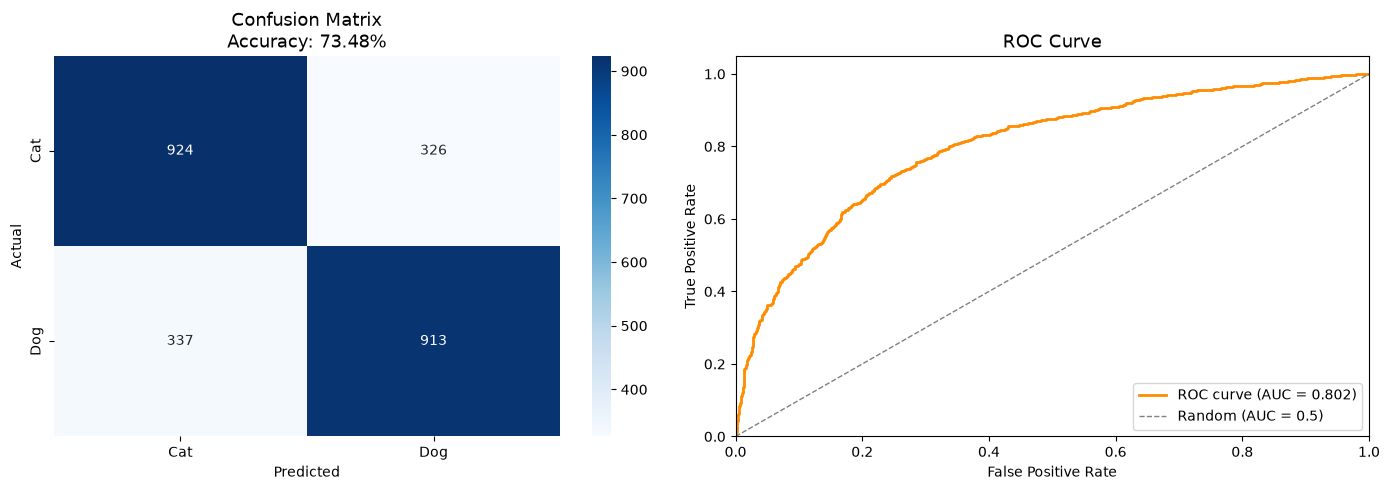


ROC-AUC Score: 0.8020
Log Loss: 0.5447


In [13]:
# Trực quan hóa Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix\nAccuracy: {acc_test*100:.2f}%', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"Log Loss: {log_loss(y_test, best_model.predict_proba(X_test)):.4f}")

## Bước 9: Phân tích Xác suất (Confidence Score) — Lọc đối tượng lạ
- **Mục đích:** Đảm bảo hệ thống đáng tin cậy. Khi người dùng đưa ảnh xe máy hoặc phong cảnh vào, mô hình sẽ không ép buộc đoán nó là Chó hay Mèo, mà phải trả về "Unknown".
- **Công cụ sử dụng:** Phương thức `.predict_proba()` của Logistic Regression để lấy xác suất %.
- **Cách hoạt động:** Thiết lập **ngưỡng (Threshold)**. Nếu xác suất dự đoán của cả 2 lớp đều `< 75%`, mô hình sẽ dán nhãn Unknown.

=== BẮT ĐẦU TEST 9 BỨC ẢNH ===


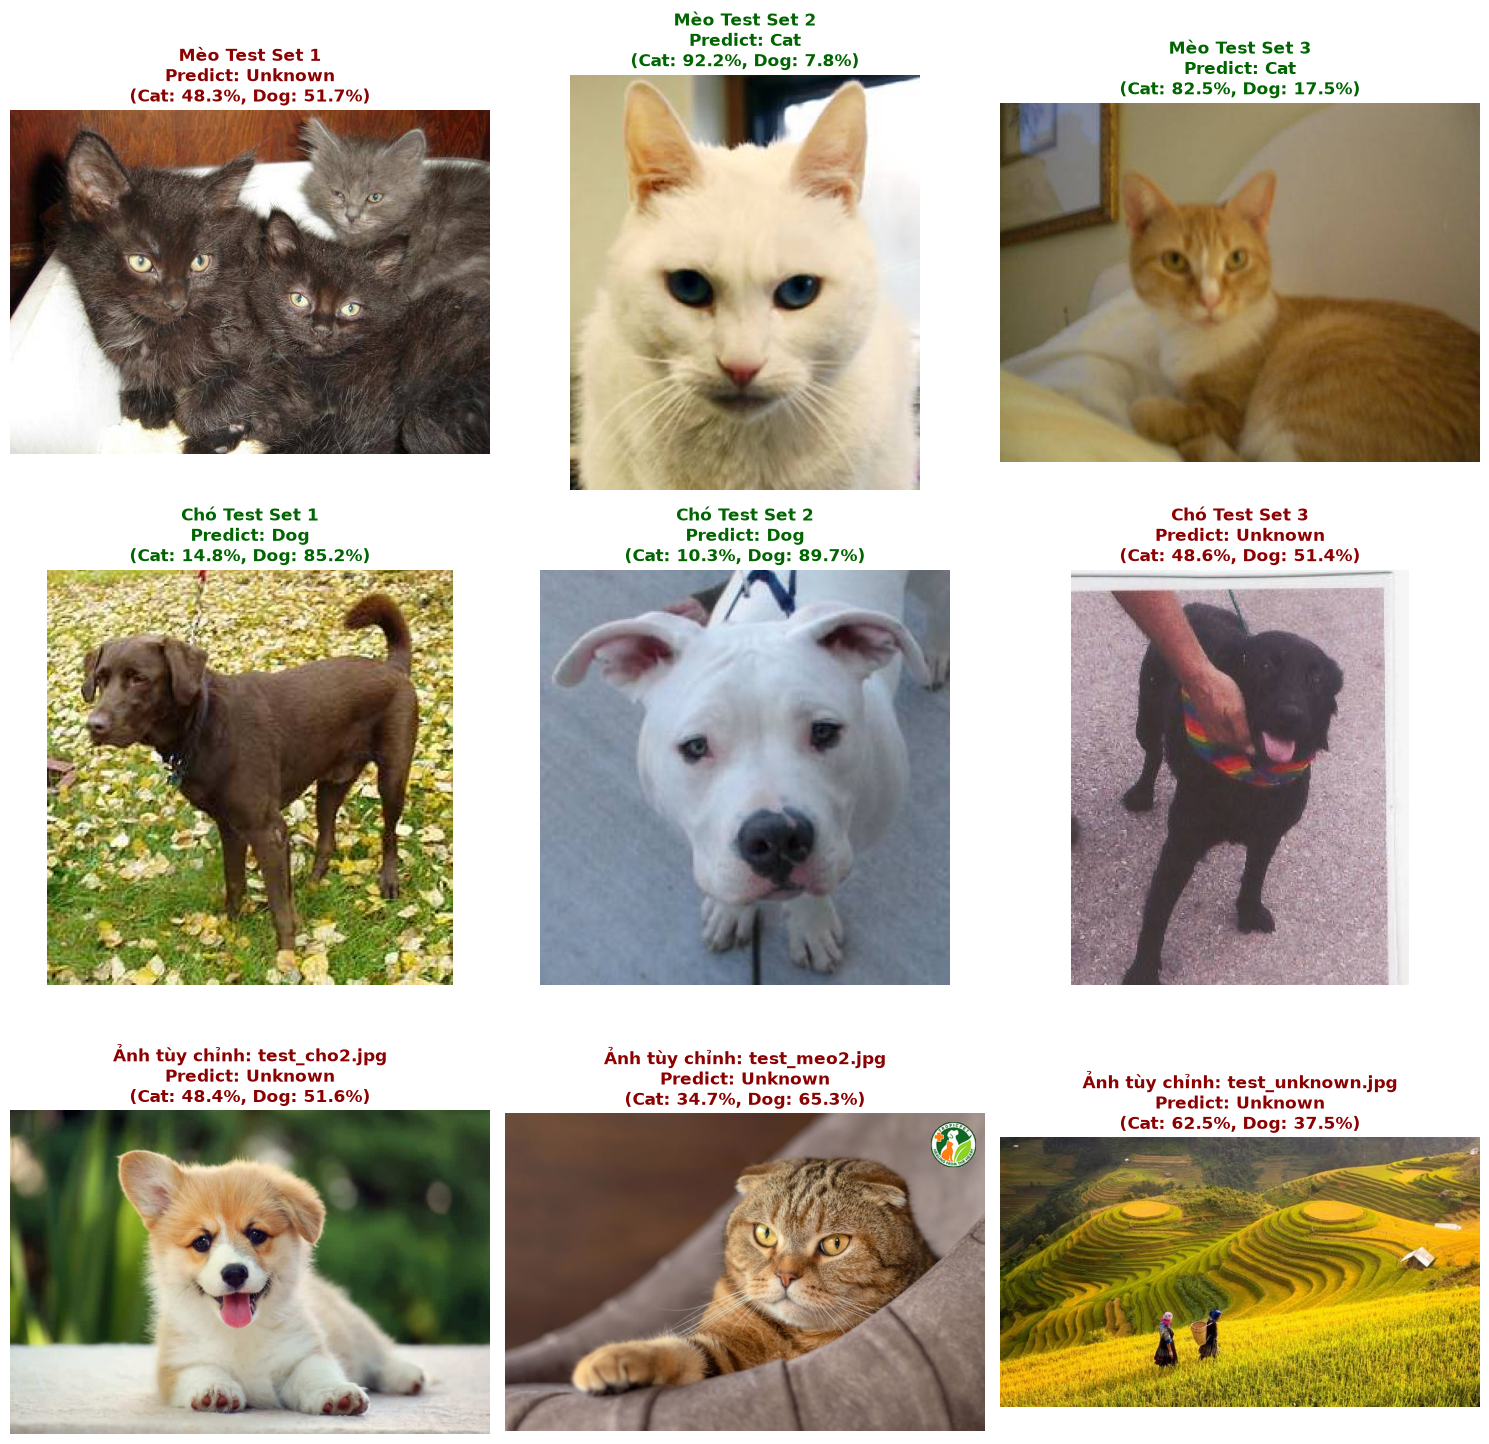

In [17]:
import math
import matplotlib.pyplot as plt

def predict_and_show(image_list, model=best_model, threshold=0.75):
    """Dự đoán và xuất ảnh trực quan trên đồ thị."""
    n = len(image_list)
    cols = 3
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i, (img_path, desc) in enumerate(image_list):
        ax = axes[i]
        
        img = cv2.imread(img_path)
        if img is None:
            ax.set_title(f"Lỗi: Không đọc được ảnh\n{desc}")
            ax.axis('off')
            continue
            
        # OpenCV đọc ảnh BGR, cần chuyển sang RGB để plt.imshow hiển thị đúng màu
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Tiền xử lý giống hệt lúc train
        img_pad = resize_with_padding(img, IMG_SIZE)
        img_gray = cv2.cvtColor(img_pad, cv2.COLOR_BGR2GRAY)
        features = hog(
            img_gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        # Ép kiểu float32 để đồng bộ
        features = features.astype(np.float32).reshape(1, -1)
        
        # Predict
        probs = model.predict_proba(features)[0]
        cat_prob = probs[0]
        dog_prob = probs[1]
        
        # Áp dụng ngưỡng
        if dog_prob >= threshold:
            result = "Dog"
        elif cat_prob >= threshold:
            result = "Cat"
        else:
            result = "Unknown"
            
        # Hiển thị ảnh kèm text
        ax.imshow(img_rgb)
        ax.set_title(f"{desc}\nPredict: {result}\n(Cat: {cat_prob*100:.1f}%, Dog: {dog_prob*100:.1f}%)", 
                     fontsize=12, fontweight='bold', color='darkred' if result == 'Unknown' else 'darkgreen')
        ax.axis('off')
        
    # Xoá các ô trống nếu có (khi số ảnh không chia hết cho 3)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# Lấy thêm vài mẫu ảnh ở tập test ra (3 mèo, 3 chó)
cat_test_dir = "Cat_Dog_data/test/cat"
dog_test_dir = "Cat_Dog_data/test/dog"

cat_files = os.listdir(cat_test_dir)
dog_files = os.listdir(dog_test_dir)

test_images = [
    (os.path.join(cat_test_dir, cat_files[1033]), "Mèo Test Set 1"),
    (os.path.join(cat_test_dir, cat_files[228]), "Mèo Test Set 2"),
    (os.path.join(cat_test_dir, cat_files[25]), "Mèo Test Set 3"),
    (os.path.join(dog_test_dir, dog_files[1002]), "Chó Test Set 1"),
    (os.path.join(dog_test_dir, dog_files[826]), "Chó Test Set 2"),
    (os.path.join(dog_test_dir, dog_files[331]), "Chó Test Set 3"),
]

# 3 ảnh tùy chỉnh ngoài bộ test
custom_images = ["test_cho2.jpg", "test_meo2.jpg", "test_unknown.jpg"]
for custom in custom_images:
    if os.path.exists(custom):
        test_images.append((custom, f"Ảnh tùy chỉnh: {custom}"))

print(f"=== BẮT ĐẦU TEST {len(test_images)} BỨC ẢNH ===")
predict_and_show(test_images, model=best_model, threshold=0.75)


## Bước 10: Xuất và lưu trữ mô hình (Export Model)
- **Mục đích:** Lưu lại toàn bộ "bộ não" của mô hình (bao gồm StandardScaler, PCA và Logistic Regression đã được train) thành một file vật lý trên ổ cứng, để dễ dàng nhúng vào Web App mà không cần train lại.
- **Công cụ sử dụng:** Thư viện `joblib` để nén và ghi model ra file `.pkl`.

In [18]:
# # === UNCOMMENT KHI SẴN SÀNG XUẤT MODEL ===

joblib.dump(best_model, "pipeline_catdog_model_final.pkl")

# Kiểm tra kích thước file
file_size = os.path.getsize("pipeline_catdog_model_final.pkl") / (1024 * 1024)
print(f"Đã xuất thành công: pipeline_catdog_model_final.pkl")
print(f"Kích thước file: {file_size:.2f} MB")
print(f"\nFile này chứa toàn bộ Pipeline (StandardScaler + PCA + LogisticRegression).")
print(f"Khi load lên Flask, chỉ cần gọi pipeline_model.predict() là tự động chạy qua tất cả các bước.")

# Verify model đã xuất
loaded_model = joblib.load("pipeline_catdog_model_final.pkl")
pred_loaded = loaded_model.predict(X_test)
acc_loaded = accuracy_score(y_test, pred_loaded)
print(f"\nAccuracy sau khi load từ file .pkl: {acc_loaded * 100:.2f}%")
print(f"Khớp với kết quả trước khi xuất: {'✓ PASS' if acc_loaded == acc_test else '✗ FAIL'}")

print("(Phần xuất model đang được comment. Uncomment khi đã test xong và sẵn sàng xuất.)")

Đã xuất thành công: pipeline_catdog_model_final.pkl
Kích thước file: 9.49 MB

File này chứa toàn bộ Pipeline (StandardScaler + PCA + LogisticRegression).
Khi load lên Flask, chỉ cần gọi pipeline_model.predict() là tự động chạy qua tất cả các bước.

Accuracy sau khi load từ file .pkl: 73.48%
Khớp với kết quả trước khi xuất: ✓ PASS
(Phần xuất model đang được comment. Uncomment khi đã test xong và sẵn sàng xuất.)
